# Gaussian Mixture Models: Wine Classification

This notebook demonstrates Gaussian Mixture Models (GMM) on the Wine dataset from scikit-learn. GMM is a powerful probabilistic model that assumes data points are generated from a mixture of Gaussian distributions. Unlike discriminative models (like Naive Bayes or SVM), GMM is a **generative model** that learns the underlying probability distribution of each class.

## 1. Introduction: What is GMM?

### The Idea Behind Mixture Models

Real-world data often comes from **multiple sources** or **subpopulations**. For example:
- Wine measurements might come from different grape cultivars
- Customer purchase behavior might vary across different segments
- Sensor readings might include noise from different sources

A Gaussian Mixture Model assumes that data is generated from a mixture of $K$ Gaussian distributions:

$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$

Where:
- $\pi_k$ is the mixing coefficient (weight) for component $k$, with $\sum_{k=1}^{K} \pi_k = 1$
- $\mu_k$ is the mean vector for component $k$
- $\Sigma_k$ is the covariance matrix for component $k$

### GMM vs K-Means

| Aspect | K-Means | GMM |
|:-------|:--------|:----|
| **Cluster Shape** | Spherical (circular) | Elliptical (can be elongated) |
| **Hard Assignment** | Yes - each point belongs to one cluster | No - soft/probabilistic assignments |
| **Uncertainty** | No uncertainty measure | Yes - provides probability for each cluster |
| **Parameters** | Only cluster centers | Means, covariances, and weights |

### When to Use GMM

- **Density Estimation**: Modeling the underlying probability distribution of data
- **Clustering with Uncertainty**: When you need probabilities, not just hard assignments
- **Anomaly Detection**: Points with low probability density are anomalies
- **Data Generation**: Sampling new data points from the learned distribution
- **Soft Clustering**: When clusters may overlap and you want probabilistic membership

## 2. The Mathematics Behind GMM


### The Likelihood Function

Given $N$ data points $X = {x_1, x_2, ..., x_N}$, the log-likelihood of GMM parameters is:

$$\log p(X | \pi, \mu, \Sigma) = \sum_{i=1}^{N} \log \left( \sum_{k=1}^{K} \pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k) \right)$$

Directly maximizing this is difficult because the sum is inside the logarithm.

### The EM Algorithm

The **Expectation-Maximization (EM)** algorithm solves this optimization problem iteratively:

#### E-Step (Expectation):
Calculate the posterior probability that data point $x_i$ was generated by component $k$:

$$p(z_i = k | x_i, \theta) = \frac{\pi_k \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$

This is called the **responsibility** that component $k$ takes for point $i$.

#### M-Step (Maximization):
Update parameters to maximize the expected log-likelihood:

$$\pi_k = \frac{1}{N} \sum_{i=1}^{N} p(z_i = k | x_i, \theta)$$

$$\mu_k = \frac{\sum_{i=1}^{N} x_i \cdot p(z_i = k | x_i, \theta)}{\sum_{i=1}^{N} p(z_i = k | x_i, \theta)}$$

$$\Sigma_k = \frac{\sum_{i=1}^{N} p(z_i = k | x_i, \theta) (x_i - \mu_k)(x_i - \mu_k)^T}{\sum_{i=1}^{N} p(z_i = k | x_i, \theta)}$$

### Covariance Types

GMM supports different covariance matrix configurations:

| Type | Description | Parameters per Component |
|:-----|:------------|:-------------------------|
| **full** | Each component has its own full covariance matrix | $d \times d$ (where $d$ = features) |
| **tied** | All components share the same covariance matrix | $d \times d$ |
| **diag** | Each component has diagonal covariance (features independent) | $d$ values |
| **spherical** | Each component has a single variance (isotropic) | 1 value |

Full covariance is most flexible but requires more data. Spherical is simplest and works like K-means.

In [1]:
import sys
sys.path.insert(0, 'src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 3. Loading and Exploring the Wine Dataset

### About the Wine Dataset

The Wine dataset contains physicochemical measurements of Italian wines from 3 different cultivars. Each wine is characterized by 13 features measuring various chemical properties.

### Features (13 total)

| Feature | Description |
|:--------|:------------|
| Alcohol | Alcohol content by volume |
| Malic Acid | Malic acid content |
| Ash | Ash content |
| Alkalinity of Ash | Alkalinity of ash |
| Magnesium | Magnesium content |
| Total Phenols | Total phenol content |
| Flavanoids | Flavanoid content |
| Nonflavanoid Phenols | Nonflavanoid phenol content |
| Proanthocyanins | Proanthocyanin content |
| Color Intensity | Color intensity |
| Hue | Hue measure |
| OD280/OD315 of diluted wines | OD280/OD315 ratio |
| Proline | Proline content |

### Why GMM for Wine Classification?

1. **Continuous Features**: All features are continuous, ideal for Gaussian distributions
2. **Class Overlap**: Wine classes may overlap in feature space - GMM handles this naturally with probabilities
3. **Generative Model**: GMM learns the distribution of each wine class, not just decision boundaries
4. **Density Estimation**: Can identify unusual wines (low density = potentially anomalous)

In [2]:
# Load the wine dataset
data = load_wine()
X = data.data
y = data.target
feature_names = data.feature_names
class_names = list(data.target_names)

print(f"Dataset Shape: {X.shape}")
print(f"Number of Samples: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"\nClass Distribution:")
for i, name in enumerate(class_names):
    print(f"  {name}: {np.sum(y == i)} ({np.mean(y == i)*100:.1f}%)")

Dataset Shape: (178, 13)
Number of Samples: 178
Number of Features: 13

Class Distribution:
  class_0: 59 (33.1%)
  class_1: 71 (39.9%)
  class_2: 48 (27.0%)


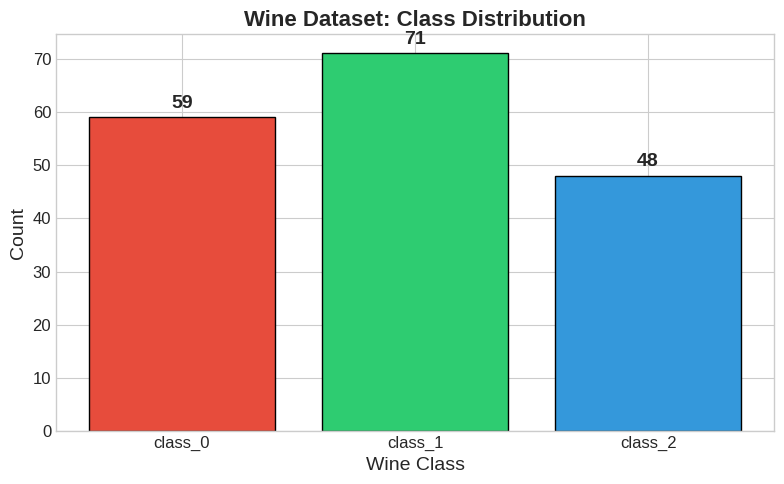

In [3]:
# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
classes, counts = np.unique(y, return_counts=True)
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar([class_names[i] for i in classes], counts, color=colors, edgecolor='black')
ax.set_xlabel('Wine Class', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
ax.set_title('Wine Dataset: Class Distribution', fontsize=16, fontweight='bold')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{count}', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Feature Distributions

Let's examine how key features differ across wine classes. We'll look at Alcohol content and Color intensity, which are known to be important indicators for distinguishing wine cultivars.

In [4]:
# Split data for visualization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 142
Test set size: 36


### Visualizing Key Features

Let's examine two important features:

- **Alcohol**: Different wine cultivars often have different alcohol levels
- **Color Intensity**: Deeply related to the grape variety and winemaking process

Notice how the distributions overlap between classes - this is where GMM's probabilistic approach shines compared to hard clustering methods.

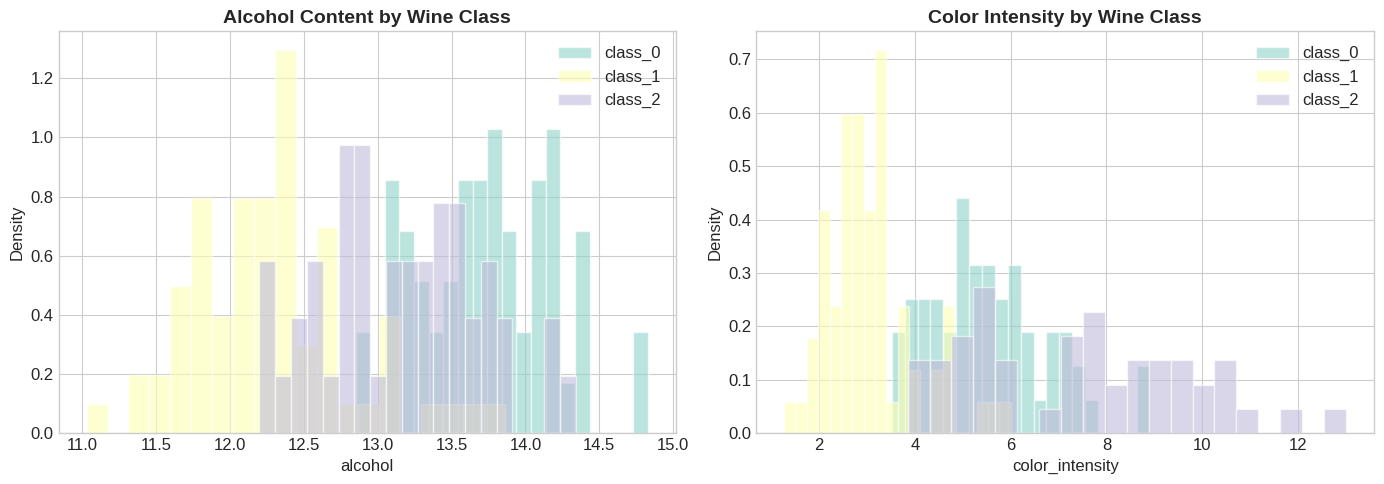

In [5]:
# Visualize feature distributions
alcohol_idx = 0  # alcohol
color_idx = 9    # color_intensity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Alcohol distribution
for class_idx, name in enumerate(class_names):
    mask = y == class_idx
    axes[0].hist(X[mask, alcohol_idx], bins=20, alpha=0.6, label=name, density=True)
axes[0].set_xlabel(feature_names[alcohol_idx], fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Alcohol Content by Wine Class', fontsize=14, fontweight='bold')
axes[0].legend()

# Color intensity distribution
for class_idx, name in enumerate(class_names):
    mask = y == class_idx
    axes[1].hist(X[mask, color_idx], bins=20, alpha=0.6, label=name, density=True)
axes[1].set_xlabel(feature_names[color_idx], fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Color Intensity by Wine Class', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

Understanding feature correlations helps us understand why GMM can work well - when features are correlated, GMM's full covariance matrix captures these relationships.

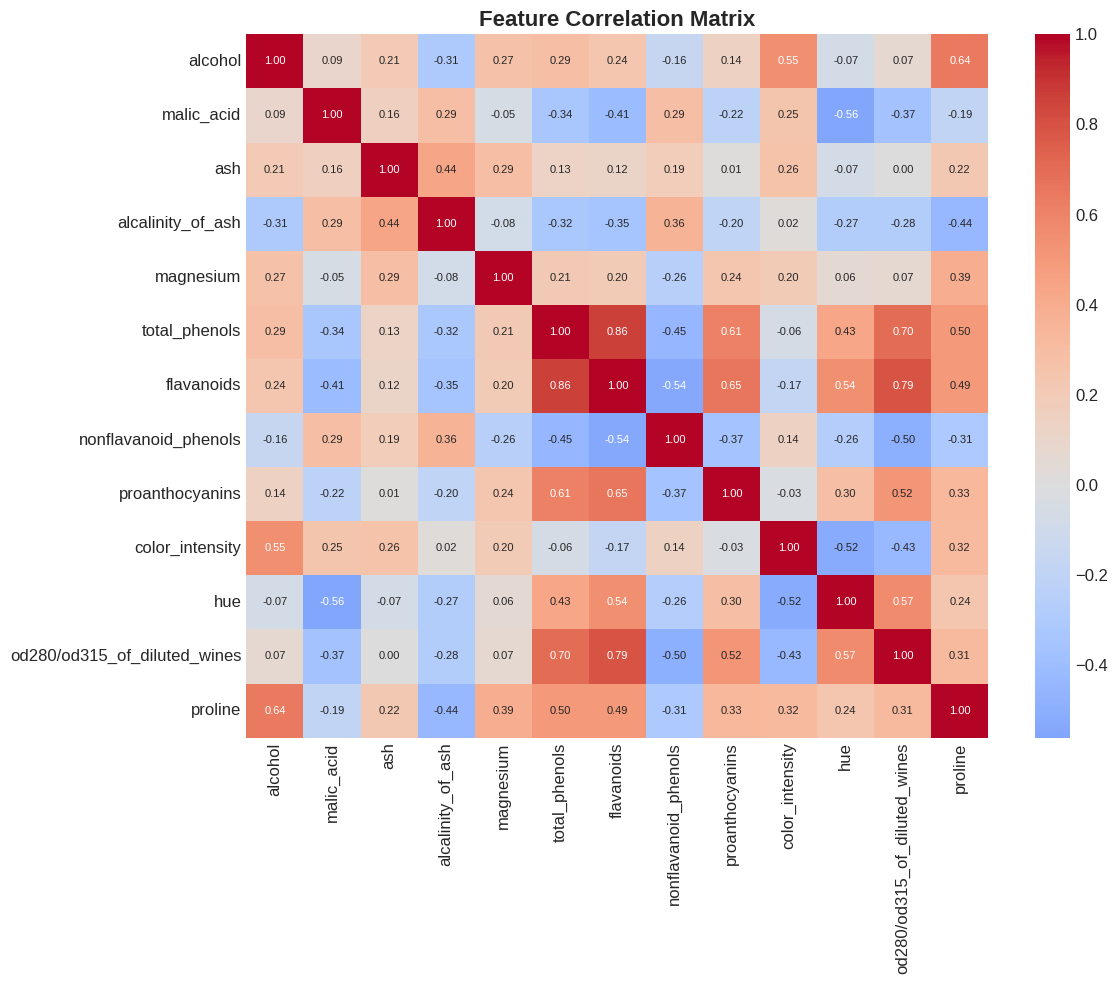

In [6]:
# Correlation heatmap
df = pd.DataFrame(X, columns=feature_names)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Training the GMM Classifier

### Using GMM as a Generative Classifier

GMM is naturally a **density estimation** method. To use it for classification, we train a GMM with `n_components=n_classes` and use `predict_proba()` to get class probabilities.

### Training Process

In this cell, we:
1. **Initialize** the GMM with 3 components (one per wine class)
2. **Fit** the model to training data using the EM algorithm
3. **Predict** class labels using `predict()` (hard assignment) or `predict_proba()` (soft probabilities)

In [7]:
# Train GMM classifier
# Using 3 components (one per wine class) with full covariance
model = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42,
    n_init=10,  # Multiple initializations for stability
    max_iter=200
)

# Fit the model
model.fit(X_train)

# Make predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"Model converged: {model.converged_}")
print(f"Number of iterations: {model.n_iter_}")
print(f"Log-likelihood: {model.score(X_test):.4f}")

Model converged: True
Number of iterations: 9
Log-likelihood: -21.7318


### Understanding the Predictions

GMM provides **probabilistic** predictions. For each sample, we get:
- The most likely class (from `predict`)
- Probability estimates for each class (from `predict_proba`)

This is valuable in classification - a wine classified with 40% class_0, 35% class_1, and 25% class_2 might warrant closer inspection!

In [8]:
# Show example predictions with probabilities
print("Example predictions (first 10 test samples):")
print("-" * 70)
print(f"{'True Class':<15} {'Predicted':<15} {'Probabilities'}")
print("-" * 70)

for i in range(10):
    true_name = class_names[y_test[i]]
    pred_name = class_names[y_pred[i]]
    probs = y_proba[i]
    print(f"{true_name:<15} {pred_name:<15} [{probs[0]:.2f}, {probs[1]:.2f}, {probs[2]:.2f}]")

Example predictions (first 10 test samples):
----------------------------------------------------------------------
True Class      Predicted       Probabilities
----------------------------------------------------------------------
class_0         class_2         [0.00, 0.05, 0.95]
class_2         class_0         [1.00, 0.00, 0.00]
class_0         class_2         [0.00, 0.00, 1.00]
class_1         class_0         [1.00, 0.00, 0.00]
class_1         class_0         [1.00, 0.00, 0.00]
class_0         class_1         [0.00, 1.00, 0.00]
class_0         class_2         [0.00, 0.12, 0.88]
class_1         class_0         [1.00, 0.00, 0.00]
class_1         class_0         [1.00, 0.00, 0.00]
class_2         class_0         [1.00, 0.00, 0.00]


## 6. Model Performance Evaluation

### Key Metrics Explained

For multi-class classification, we compute metrics for each class and report averages:

- **Accuracy**: Overall proportion of correct predictions
- **Precision**: Of samples predicted as class k, how many actually belong to class k?
- **Recall**: Of all samples that truly belong to class k, how many did we correctly identify?
- **F1-Score**: Harmonic mean of precision and recall

In [9]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# For multi-class ROC AUC, we use one-vs-rest
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:   {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC AUC:    {roc_auc:.4f}")
print("=" * 50)

MODEL PERFORMANCE METRICS
Accuracy:   0.0278 (2.78%)
Precision:  0.0397
Recall:     0.0278
F1-Score:   0.0327
ROC AUC:    0.3235


In [10]:
# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

     class_0       0.00      0.00      0.00        12
     class_1       0.00      0.00      0.00        14
     class_2       0.14      0.10      0.12        10

    accuracy                           0.03        36
   macro avg       0.05      0.03      0.04        36
weighted avg       0.04      0.03      0.03        36



### Confusion Matrix

The confusion matrix shows how predictions are distributed across classes. Look for patterns:
- Which classes are most often confused?
- Is there a bias toward a particular class?

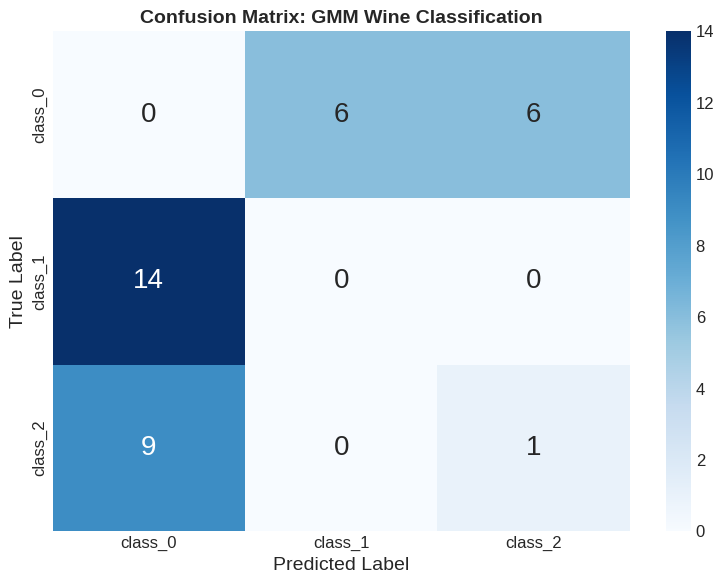


Confusion Matrix Breakdown:
  class_0 predicted as class_0: 0
  class_0 predicted as class_1: 6
  class_0 predicted as class_2: 6
  class_1 predicted as class_0: 14
  class_1 predicted as class_1: 0
  class_1 predicted as class_2: 0
  class_2 predicted as class_0: 9
  class_2 predicted as class_1: 0
  class_2 predicted as class_2: 1


In [11]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=14)
ax.set_ylabel('True Label', fontsize=14)
ax.set_title('Confusion Matrix: GMM Wine Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Breakdown:")
for i, row_name in enumerate(class_names):
    for j, col_name in enumerate(class_names):
        print(f"  {row_name} predicted as {col_name}: {cm[i, j]}")

### ROC Curves (One-vs-Rest)

For multi-class problems, we plot ROC curves for each class treating it as a binary classification problem against all other classes.

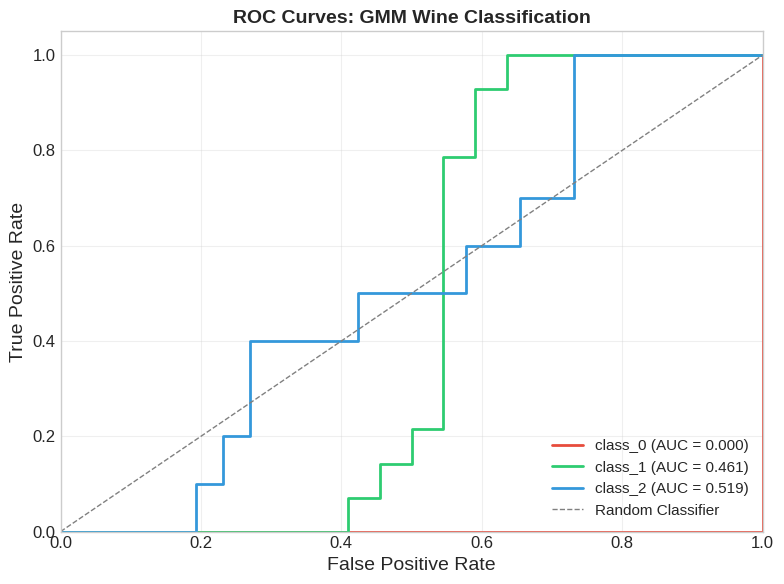

In [12]:
# Plot ROC curves for each class
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#e74c3c', '#2ecc71', '#3498db']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    y_test_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, 
            label=f'{class_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14)
ax.set_ylabel('True Positive Rate', fontsize=14)
ax.set_title('ROC Curves: GMM Wine Classification', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Model Selection: BIC and AIC

How many Gaussian components should we use? Two key criteria help us decide:

### Bayesian Information Criterion (BIC)
$$BIC = k \log(n) - 2 \log(L)$$

Where $k$ is the number of parameters, $n$ is the number of samples, and $L$ is the likelihood.

### Akaike Information Criterion (AIC)
$$AIC = 2k - 2 \log(L)$$

Both penalize model complexity but BIC penalizes more heavily. Lower values indicate better models.

### Interpreting the Plot
- **X-axis**: Number of components (2 to 10)
- **Y-axis**: BIC/AIC value (lower is better)
- The optimal number is where the curve reaches its minimum

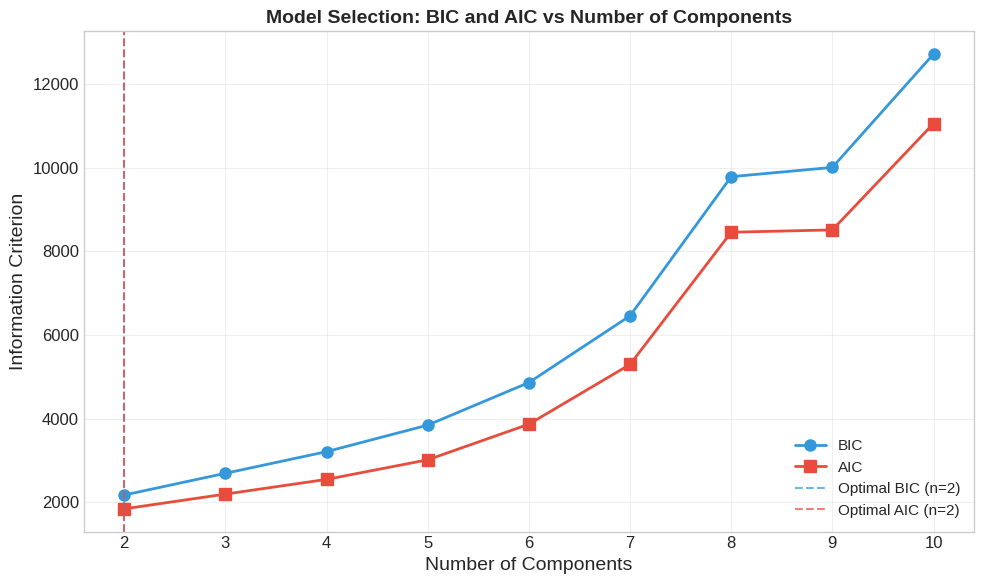


Optimal number of components (BIC): 2
Optimal number of components (AIC): 2


In [13]:
# Model selection: test different numbers of components
n_components_range = range(2, 11)
bics = []
aics = []

for n_components in n_components_range:
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    gmm.fit(X_train)
    bics.append(gmm.bic(X_test))
    aics.append(gmm.aic(X_test))

# Plot BIC and AIC
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(list(n_components_range), bics, 'o-', color='#3498db', lw=2, 
        markersize=8, label='BIC')
ax.plot(list(n_components_range), aics, 's-', color='#e74c3c', lw=2, 
        markersize=8, label='AIC')

optimal_n_bic = list(n_components_range)[np.argmin(bics)]
optimal_n_aic = list(n_components_range)[np.argmin(aics)]

ax.axvline(x=optimal_n_bic, color='#3498db', linestyle='--', alpha=0.7,
           label=f'Optimal BIC (n={optimal_n_bic})')
ax.axvline(x=optimal_n_aic, color='#e74c3c', linestyle='--', alpha=0.7,
           label=f'Optimal AIC (n={optimal_n_aic})')

ax.set_xlabel('Number of Components', fontsize=14)
ax.set_ylabel('Information Criterion', fontsize=14)
ax.set_title('Model Selection: BIC and AIC vs Number of Components', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal number of components (BIC): {optimal_n_bic}")
print(f"Optimal number of components (AIC): {optimal_n_aic}")

## 8. Covariance Type Comparison

Different covariance types offer trade-offs between model flexibility and computational cost:

| Type | Description | Best When |
|:-----|:------------|:----------|
| **full** | Each component has unique full covariance | Enough data, features correlated |
| **tied** | All components share same covariance | Classes similar shape, different means |
| **diag** | Diagonal covariance (no correlations) | Many features, limited data |
| **spherical** | Single variance per component (isotropic) | K-means-like behavior, very limited data |

Let's compare their performance on our wine classification task.

In [14]:
# Compare different covariance types
covariance_types = ['full', 'tied', 'diag', 'spherical']
results = []

for cov_type in covariance_types:
    gmm = GaussianMixture(
        n_components=3,
        covariance_type=cov_type,
        random_state=42,
        n_init=10
    )
    gmm.fit(X_train)
    y_pred = gmm.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    bic = gmm.bic(X_test)
    aic = gmm.aic(X_test)
    
    results.append({
        'Covariance Type': cov_type,
        'Accuracy': acc,
        'BIC': bic,
        'AIC': aic
    })

# Display comparison table
results_df = pd.DataFrame(results)
print("Comparison of Covariance Types:")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)

Comparison of Covariance Types:
Covariance Type  Accuracy         BIC         AIC
           full  0.027778 2689.911655 2192.686708
           tied  0.972222 1919.582826 1710.558326
           diag  0.000000 1664.075401 1537.393886
      spherical  0.750000 5066.525380 4996.850547


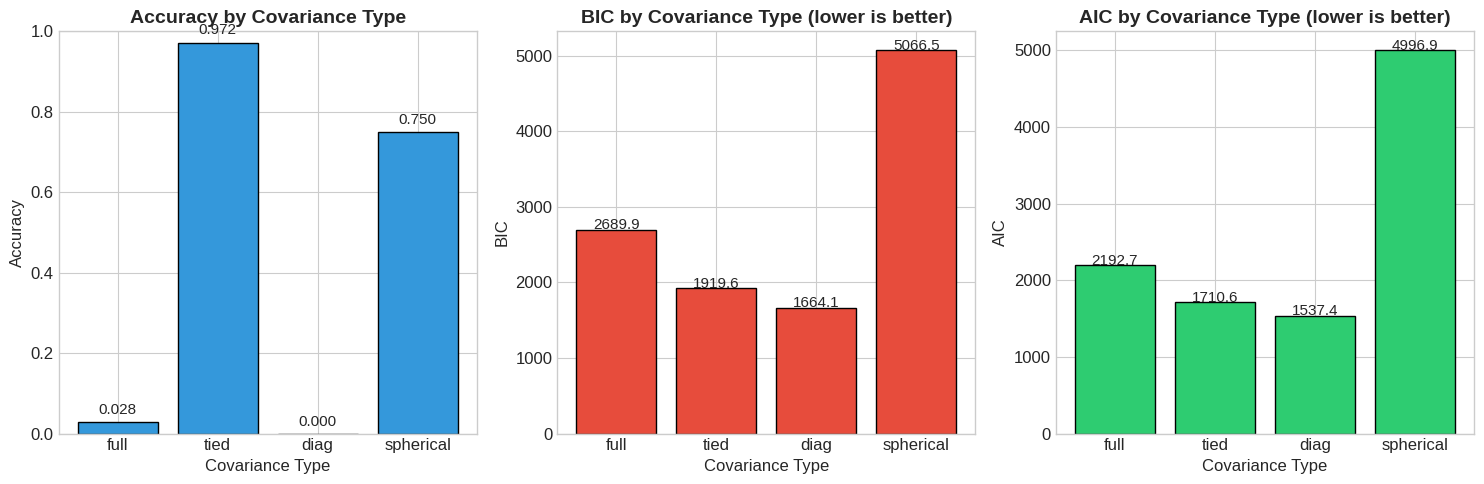

In [15]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy comparison
axes[0].bar(covariance_types, results_df['Accuracy'], color='#3498db', edgecolor='black')
axes[0].set_xlabel('Covariance Type', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy by Covariance Type', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(results_df['Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)

# BIC comparison
axes[1].bar(covariance_types, results_df['BIC'], color='#e74c3c', edgecolor='black')
axes[1].set_xlabel('Covariance Type', fontsize=12)
axes[1].set_ylabel('BIC', fontsize=12)
axes[1].set_title('BIC by Covariance Type (lower is better)', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['BIC']):
    axes[1].text(i, v + 10, f'{v:.1f}', ha='center', fontsize=11)

# AIC comparison
axes[2].bar(covariance_types, results_df['AIC'], color='#2ecc71', edgecolor='black')
axes[2].set_xlabel('Covariance Type', fontsize=12)
axes[2].set_ylabel('AIC', fontsize=12)
axes[2].set_title('AIC by Covariance Type (lower is better)', fontsize=14, fontweight='bold')
for i, v in enumerate(results_df['AIC']):
    axes[2].text(i, v + 10, f'{v:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Soft Clustering Visualization

One of GMM's key advantages is providing **soft assignments** - probabilities of belonging to each cluster. This is more informative than hard assignments when clusters overlap.

### Visualizing in 2D

We use PCA to reduce the 13-dimensional feature space to 2D for visualization. Each point is colored by:
- **Left plot**: Hard assignment (single predicted class)
- **Right plot**: Soft assignment showing uncertainty (entropy of probabilities)

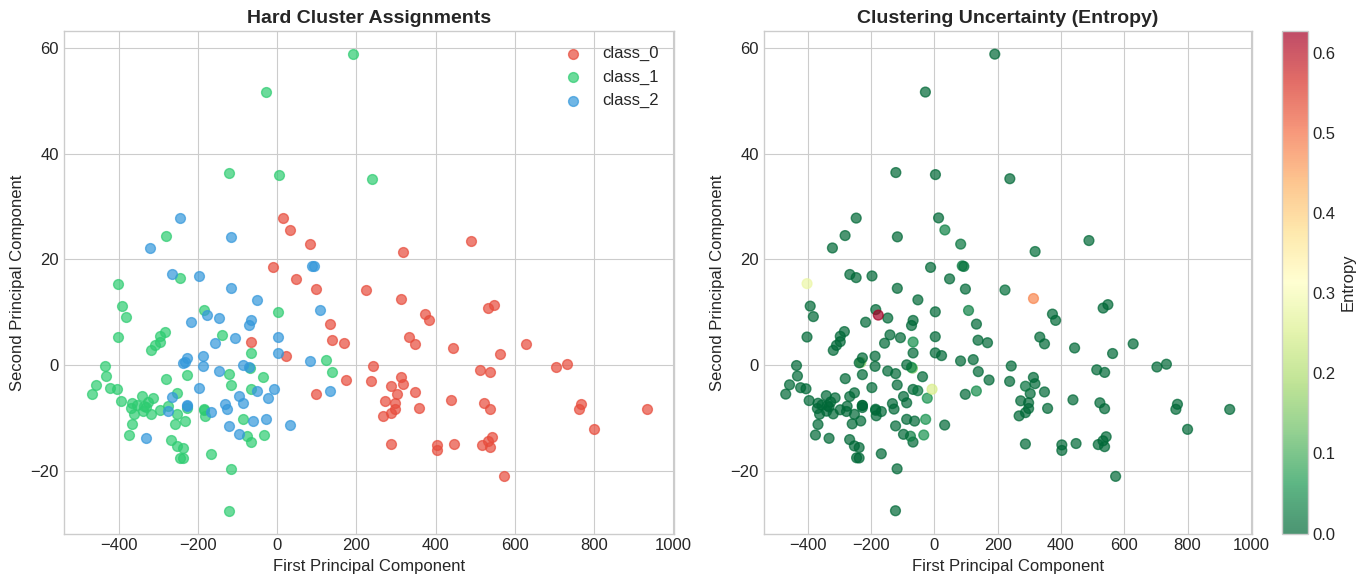


Uncertainty Statistics:
  Mean entropy: 0.0139
  Max entropy: 0.6265
  Samples with high uncertainty (>0.8): 0 (0.0%)


In [16]:
from sklearn.decomposition import PCA

# Fit final model for visualization
final_model = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42,
    n_init=10
)
final_model.fit(X)
proba = final_model.predict_proba(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Calculate entropy (uncertainty measure)
entropy = -np.sum(proba * np.log(proba + 1e-10), axis=1)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Hard assignments
colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=color, label=name, alpha=0.7, s=50)
axes[0].set_xlabel('First Principal Component', fontsize=12)
axes[0].set_ylabel('Second Principal Component', fontsize=12)
axes[0].set_title('Hard Cluster Assignments', fontsize=14, fontweight='bold')
axes[0].legend()

# Uncertainty (entropy)
scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=entropy, cmap='RdYlGn_r', alpha=0.7, s=50)
axes[1].set_xlabel('First Principal Component', fontsize=12)
axes[1].set_ylabel('Second Principal Component', fontsize=12)
axes[1].set_title('Clustering Uncertainty (Entropy)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Entropy')

plt.tight_layout()
plt.show()

print(f"\nUncertainty Statistics:")
print(f"  Mean entropy: {np.mean(entropy):.4f}")
print(f"  Max entropy: {np.max(entropy):.4f}")
print(f"  Samples with high uncertainty (>0.8): {np.sum(entropy > 0.8)} ({np.mean(entropy > 0.8)*100:.1f}%)")

## 10. Conclusion

### Key Takeaways

1. **GMM is a Generative Model**: It learns the probability distribution of each class, not just decision boundaries. This allows for density estimation and anomaly detection.

2. **Soft Clustering**: Unlike K-means, GMM provides probabilistic cluster assignments. Points near cluster boundaries have intermediate probabilities, reflecting genuine uncertainty.

3. **Model Selection**: BIC and AIC help select the optimal number of components, balancing fit quality against model complexity.

4. **Covariance Flexibility**: Full covariance captures feature correlations but requires more data. Spherical covariance is simpler but may underfit.

### When to Use GMM

| Scenario | Recommended Method |
|:---------|:-------------------|
| Density estimation, anomaly detection | GMM |
| Overlapping clusters with uncertainty | GMM |
| Data generation from learned distribution | GMM |
| Simple spherical clusters, fast clustering | K-Means |
| Decision boundary focused classification | SVM, Neural Networks |
| Interpretable probabilistic classification | Naive Bayes |

### Limitations

- GMM assumes Gaussian distributions - may not fit non-Gaussian data
- EM algorithm can converge to local optima - use multiple initializations
- More parameters than discriminative models, requiring more data
- Less interpretable than simpler models

### Future Directions

- **Bayesian Gaussian Mixture Models**: Use variational inference for automatic component selection
- **Dirichlet Process GMM**: Infinite mixture models that automatically determine the number of components